# 02 · Machine Learning — CAFV Classifier & Range Regressor

## Problems
1. **CAFV Eligibility Classifier** (3-class) — 41% of records are 'unknown'. Can we predict eligibility from vehicle attributes?
2. **Electric Range Regressor** — Given make, year, and EV type, can we predict range better than a simple group-median baseline?

All modelling uses XGBoost. SHAP is used for explainability.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from src import visualizations as viz
from src.features import full_preprocessing_pipeline
from src.models import (
    predict_cafv,
    save_model,
    save_transformer,
    train_cafv_classifier,
    train_range_regressor,
)

DATA_PATH = Path("../data/raw/Electric_Vehicle_Population_Data.csv")
MODEL_DIR = Path("../data/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = full_preprocessing_pipeline(DATA_PATH)
print(f"Dataset shape: {df.shape}")


import logging

import mlflow

logging.getLogger("mlflow.models.model").setLevel(logging.ERROR)
import mlflow.xgboost
import optuna

MLFLOW_EXPERIMENT = "ev-population-analysis"
mlflow.set_tracking_uri(f"sqlite:///{Path('..').resolve() / 'mlflow.db'}")
mlflow.set_experiment(MLFLOW_EXPERIMENT)

# Autologs XGBClassifier/XGBRegressor .fit() calls:
# hyperparams, per-iteration eval metrics, model artifact, feature importance.
# Must be active BEFORE train_cafv_classifier() / train_range_regressor().
mlflow.xgboost.autolog(
    log_input_examples=False,
    log_model_signatures=True,
    disable_for_unsupported_versions=True,
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment          : {MLFLOW_EXPERIMENT}")


Dataset shape: (177866, 17)
MLflow tracking URI : sqlite:///C:\Users\victas\ml_projects\mlflow.db
Experiment          : ev-population-analysis


## 1 · CAFV Eligibility Classifier

**Target classes:**
- `0` → eligible (46.4%)
- `1` → not_eligible (12.6%)
- `2` → unknown (41.0%)

**Key constraint**: `Electric Range` IS available for known records but is 0 for unknowns. This is intentionally included as a feature — it's one of the strongest signals.

In [ ]:
with mlflow.start_run(run_name="cafv-classifier") as cafv_run:

    results_cafv = train_cafv_classifier(df, random_state=42, n_trials=40)
    model_cafv   = results_cafv["model"]
    agg_cafv     = results_cafv["agg_transformer"]

    save_model(model_cafv, MODEL_DIR, "cafv_classifier")
    save_transformer(agg_cafv, MODEL_DIR, "cafv_classifier")

    # ── Metrics autolog doesn't capture ──────────────────────────────────────
    cv_scores = results_cafv["cv_scores"]
    report    = results_cafv["report"]

    mlflow.log_params({
        "random_state"     : 42,
        "n_optuna_trials"  : 40,
        "hpo_subsample_frac": 0.60,
        "cv_folds"         : 5,
        "cv_scoring"       : "f1_macro",
        "n_classes"        : 3,
        "class_names"      : "eligible, not_eligible, unknown",
        "features"         : str(list(results_cafv["X_train"].columns)),
    })
    mlflow.log_metrics({
        "cv_f1_macro_mean"   : float(cv_scores.mean()),
        "cv_f1_macro_std"    : float(cv_scores.std()),
        "test_f1_eligible"   : report["eligible"]["f1-score"],
        "test_f1_not_eligible": report["not_eligible"]["f1-score"],
        "test_f1_unknown"    : report["unknown"]["f1-score"],
        "test_f1_macro"      : report["macro avg"]["f1-score"],
        "test_precision_macro": report["macro avg"]["precision"],
        "test_recall_macro"  : report["macro avg"]["recall"],
        "best_iteration"     : model_cafv.best_iteration,
    })
    mlflow.log_artifact(
        str(MODEL_DIR / "cafv_classifier_agg_transformer.joblib"),
        artifact_path="transformers",
    )

    # Log best Optuna trial params explicitly so they surface at parent-run level
    if results_cafv["study"] is not None:
        mlflow.log_params({
            f"best_{k}": v for k, v in results_cafv["study"].best_params.items()
        })
        mlflow.log_metric("optuna_best_cv_f1_macro", results_cafv["study"].best_value)

    print(f"Run ID       : {cafv_run.info.run_id}")
    print(f"CV F1-macro  : {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}")
    print(f"Test F1-macro: {report['macro avg']['f1-score']:.4f}")
    print(f"Best iter    : {model_cafv.best_iteration} / {model_cafv.n_estimators}")


  0%|          | 0/40 [00:00<?, ?it/s]

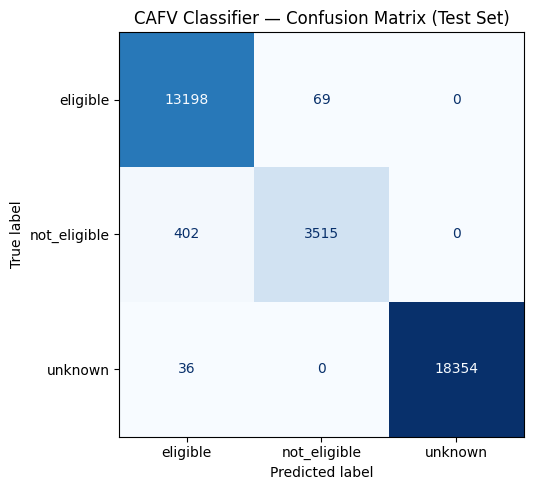

In [11]:
# Confusion matrix
cm = confusion_matrix(results_cafv["y_test"], results_cafv["model"].predict(results_cafv["X_test"]))
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["eligible", "not_eligible", "unknown"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("CAFV Classifier — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


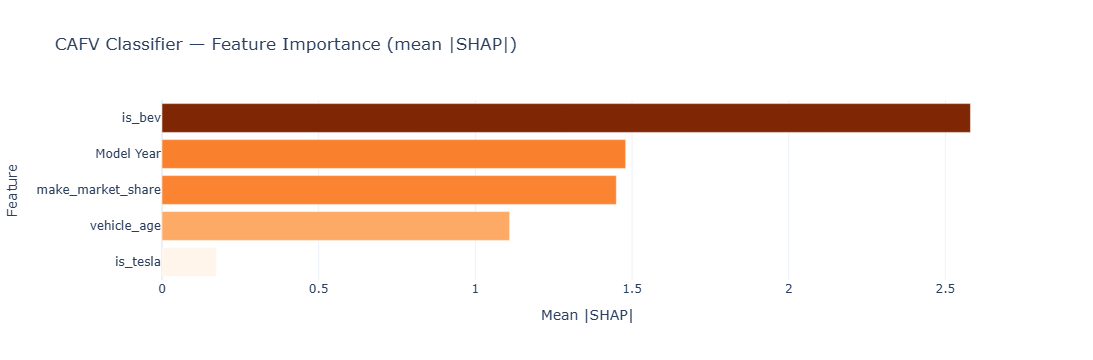

In [12]:
# SHAP explainability — CAFV classifier
explainer_cafv = shap.TreeExplainer(model_cafv)
shap_vals_cafv = explainer_cafv.shap_values(results_cafv["X_test"].sample(2000, random_state=42))

# Mean |SHAP| across all classes — handles both SHAP output shapes:
#   list of arrays : (n_classes,) list of (n_samples, n_features)  → older SHAP
#   single ndarray : (n_samples, n_features, n_classes)            → newer SHAP
shap_arr = np.abs(np.array(shap_vals_cafv))   # always produces a 3D ndarray

if shap_arr.ndim == 3:
    n_features = results_cafv["X_test"].shape[1]
    # Identify which axis is n_features, reduce the other two
    feat_axis = next(i for i, s in enumerate(shap_arr.shape) if s == n_features)
    reduce_axes = tuple(i for i in range(3) if i != feat_axis)
    mean_shap_vals = shap_arr.mean(axis=reduce_axes)
elif shap_arr.ndim == 2:                       # binary / single-output fallback
    mean_shap_vals = shap_arr.mean(axis=0)
else:
    raise ValueError(f"Unexpected shap_values shape: {shap_arr.shape}")

mean_shap = pd.Series(mean_shap_vals, index=results_cafv["X_test"].columns, name="mean_shap")
viz.plot_shap_bar(mean_shap, title="CAFV Classifier — Feature Importance (mean |SHAP|)")

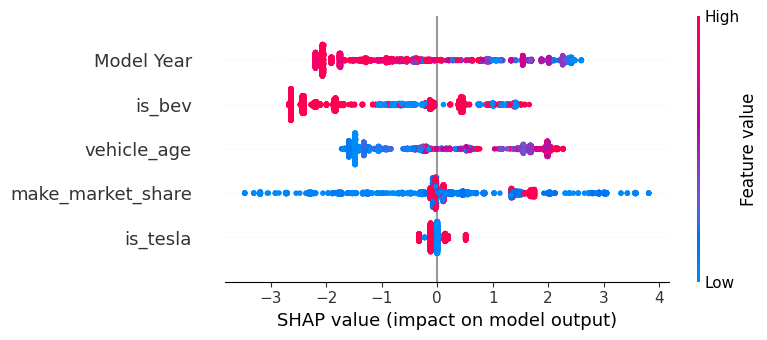

In [13]:
# SHAP beeswarm for class 0 (eligible)
# shap_vals_cafv is:
#   list of arrays → older SHAP (<0.41): shap_vals_cafv[0] is (n_samples, n_features)
#   3D ndarray     → newer SHAP (>=0.41, as pinned in requirements): [:, :, 0] for class 0
if isinstance(shap_vals_cafv, list):
    shap_for_plot = shap_vals_cafv[0]
else:
    shap_for_plot = shap_vals_cafv[:, :, 0]  # class 0 = eligible

shap.summary_plot(
    shap_for_plot,
    results_cafv["X_test"].sample(2000, random_state=42),
    plot_type="dot",
    show=True,
    max_display=10,
)


## 2 · Electric Range Regressor

Only non-zero range records are used (zero = unverified, not real zero range).

In [14]:
with mlflow.start_run(run_name="range-regressor") as range_run:

    results_range = train_range_regressor(df, random_state=42, n_trials=40)
    model_range   = results_range["model"]
    agg_range     = results_range["agg_transformer"]

    save_model(model_range, MODEL_DIR, "range_regressor")
    save_transformer(agg_range, MODEL_DIR, "range_regressor")

    m = results_range["metrics"]
    mlflow.log_params({
        "random_state"      : 42,
        "n_optuna_trials"   : 40,
        "hpo_subsample_frac": 0.60,
        "cv_folds"          : 5,
        "cv_scoring"        : "neg_mean_absolute_error",
        "zero_range_excluded": True,
        "baseline_strategy" : "median by BEV/PHEV group (train only)",
        "features"          : str(list(results_range["X_train"].columns)),
    })
    mlflow.log_metrics({
        "test_mae"           : m["mae"],
        "test_rmse"          : m["rmse"],
        "test_r2"            : m["r2"],
        "baseline_mae"       : m["baseline_mae"],
        "mae_improvement_pct": (1 - m["mae"] / m["baseline_mae"]) * 100,
        "best_iteration"     : model_range.best_iteration,
    })
    mlflow.log_artifact(
        str(MODEL_DIR / "range_regressor_agg_transformer.joblib"),
        artifact_path="transformers",
    )
    if results_range["study"] is not None:
        mlflow.log_params({
            f"best_{k}": v for k, v in results_range["study"].best_params.items()
        })
        mlflow.log_metric("optuna_best_cv_mae", -results_range["study"].best_value)

    print(f"Run ID  : {range_run.info.run_id}")
    print("\nRange Regressor Results:")
    print(f"  MAE  : {m['mae']:.2f} miles   (baseline: {m['baseline_mae']:.2f} miles)")
    print(f"  RMSE : {m['rmse']:.2f} miles")
    print(f"  R\u00b2   : {m['r2']:.4f}")
    print(f"  Improvement over baseline MAE: {(1 - m['mae']/m['baseline_mae'])*100:.1f}%")


  0%|          | 0/40 [00:00<?, ?it/s]

2026/05/17 06:56:03 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\TEMP\tmpe7_8893p\model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 


Run ID  : 0f95938ecddc4b20a23cfa9a6fb2c24d

Range Regressor Results:
  MAE  : 5.28 miles   (baseline: 35.90 miles)
  RMSE : 11.88 miles
  R²   : 0.9858
  Improvement over baseline MAE: 85.3%


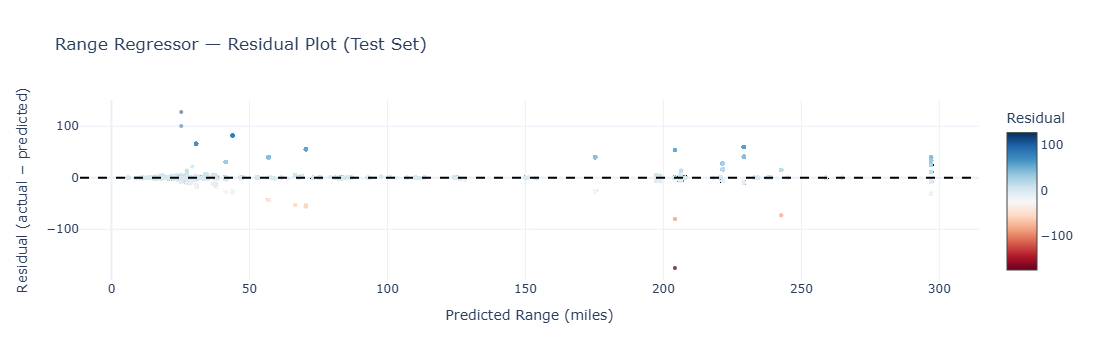

In [15]:
viz.plot_residuals(
    results_range["y_test"],
    results_range["y_pred"],
    title="Range Regressor — Residual Plot (Test Set)"
)


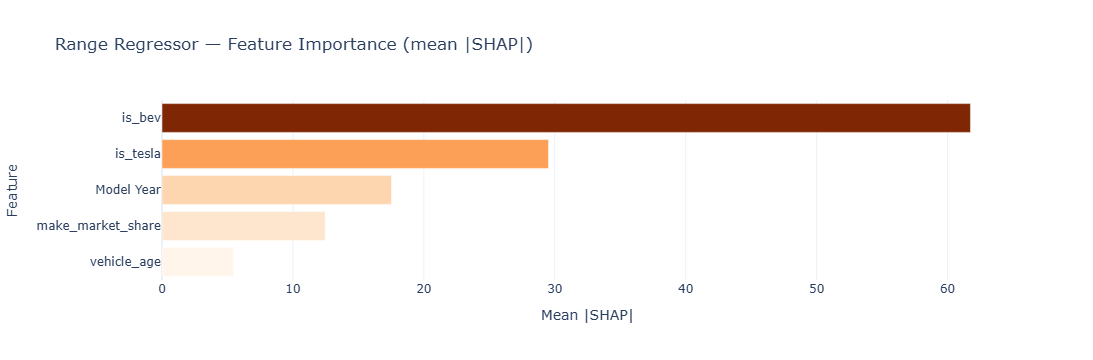

In [16]:
# SHAP for range regressor
explainer_range = shap.TreeExplainer(model_range)
X_sample = results_range["X_test"].sample(2000, random_state=42)
shap_vals_range = explainer_range.shap_values(X_sample)

mean_shap_range = pd.Series(
    np.abs(shap_vals_range).mean(axis=0),
    index=X_sample.columns,
    name="mean_shap",
)
viz.plot_shap_bar(mean_shap_range, title="Range Regressor — Feature Importance (mean |SHAP|)")


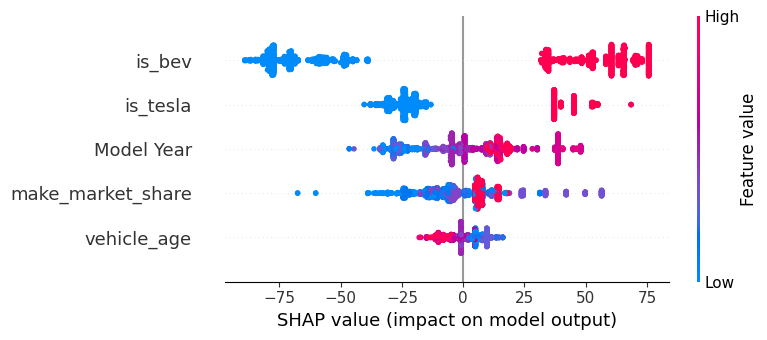

In [17]:
shap.summary_plot(shap_vals_range, X_sample, plot_type="dot", show=True, max_display=8)


## 3 · Predicted CAFV for 'Unknown' Records

Apply the trained classifier to the 53,446 'unknown' records to estimate how many are likely eligible vs not eligible.

In [18]:
unknown_mask = df["cafv_label"] == "unknown"
df_unknown   = df[unknown_mask].copy()

# predict_cafv() applies agg_cafv.transform() internally before scoring —
# make_market_share is computed from training distribution, not from df.
preds = predict_cafv(df_unknown, model_cafv, agg_cafv)

pred_series = pd.Series(preds, index=df_unknown.index)
print("Predicted CAFV class distribution for 'unknown' records:")
counts = pred_series.value_counts().rename({0: "eligible", 1: "not_eligible", 2: "unknown"})
print(counts)
print()
print(f"Of the {unknown_mask.sum():,} 'unknown' records, "
      f"~{(preds == 0).sum():,} ({100*(preds==0).mean():.1f}%) are predicted eligible.")


Predicted CAFV class distribution for 'unknown' records:
unknown     91746
eligible      204
Name: count, dtype: int64

Of the 91,950 'unknown' records, ~204 (0.2%) are predicted eligible.
